## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))
# 
# Enable autoreload for Jupyter notebooks
%load_ext autoreload
%autoreload 2

from paths import DATA_DATASETS

Failed to read module file 'C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in

In [2]:
# Load data
baseline_pred = pd.read_csv(DATA_DATASETS / "pred.csv")
test = pd.read_csv(DATA_DATASETS / "test_customers.csv", sep=";")
transactions = pd.read_csv(DATA_DATASETS / "transactions_processed.csv", sep=";")
transactions["date"] = pd.to_datetime(transactions["date"])

baseline_pred = baseline_pred.rename(columns={"Id": "customer.id", "predicted.period.CLV": "revenue_23_24_baseline_CLVEuler"})

In [3]:
test = test.merge(baseline_pred[["customer.id", "revenue_23_24_baseline_CLVEuler"]], left_on="customer.id", right_on="customer.id", how="left")

# Check for NaN values in the baseline prediction
print("Test customers total:", len(test))
print("With baseline prediction:", test["revenue_23_24_baseline_CLVEuler"].notna().sum())
print("Without baseline prediction (NaN):", test["revenue_23_24_baseline_CLVEuler"].isna().sum())

Test customers total: 7253
With baseline prediction: 7245
Without baseline prediction (NaN): 8


In [4]:
test["revenue_23_24_baseline_CLVEuler"] = test["revenue_23_24_baseline_CLVEuler"].fillna(0)

In [5]:
# Export test_customers.csv
test.to_csv(DATA_DATASETS / "test_customers.csv", index=False)

Analyse Baseline CLV predictions from TA code

In [6]:
test["revenue_23_24_baseline_CLVEuler"].describe()

count      7253.000000
mean       2336.070213
std        9250.438565
min           0.000000
25%           5.344678
50%           9.481593
75%          36.141412
max      135334.956717
Name: revenue_23_24_baseline_CLVEuler, dtype: float64

**Interpretation:** 75% quantile is at 36 NOK which is less then 1 CHF. The mean is at 2336 NOK which shows that the predictions are heavily skewed. Just a few people of the 7000 customers seem to be active and still renting things (This is at least what the baseline predicts). This observation also makes sense regarding the long time frame of the dataset from 2016 to 2023.  

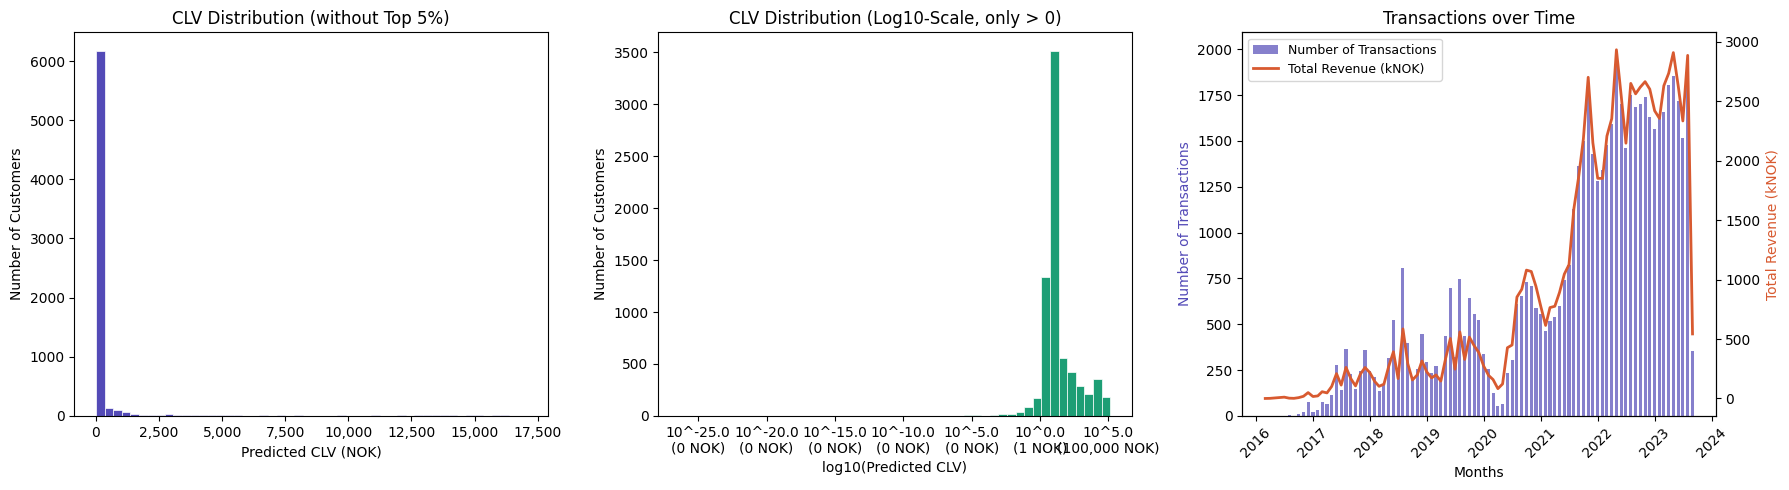

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CLV distribution (linear, without outliers)
ax1 = axes[0]
clv = test["revenue_23_24_baseline_CLVEuler"]
clv_clipped = clv[clv < clv.quantile(0.95)] # Remove top 5% to reduce skewness for better visualization
ax1.hist(clv_clipped, bins=50, color="#534AB7", edgecolor="white", linewidth=0.5)
ax1.set_title("CLV Distribution (without Top 5%)")
ax1.set_xlabel("Predicted CLV (NOK)")
ax1.set_ylabel("Number of Customers")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# CLV distribution with log10 scale (only > 0)
ax2 = axes[1]
clv_nonzero = clv[clv > 0]
ax2.hist(np.log10(clv_nonzero), bins=50, color="#1D9E75", edgecolor="white", linewidth=0.5)
ax2.set_title("CLV Distribution (Log10-Scale, only > 0)")
ax2.set_xlabel("log10(Predicted CLV)")
ax2.set_ylabel("Number of Customers")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"10^{x:.1f}\n({10**x:,.0f} NOK)"))

# Time Series
ax3 = axes[2]
transactions["month"] = transactions["date"].dt.to_period("M")
monthly = transactions.groupby("month").agg(
    n_transactions=("revenue", "count"),
    total_revenue=("revenue", "sum")
).reset_index()
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

ax3.bar(monthly["month_dt"], monthly["n_transactions"], 
        color="#534AB7", alpha=0.7, width=20, label="Number of Transactions")
ax3_twin = ax3.twinx()
ax3_twin.plot(monthly["month_dt"], monthly["total_revenue"] / 1000, 
              color="#D85A30", linewidth=2, label="Total Revenue (kNOK)")
ax3.set_title("Transactions over Time")
ax3.set_xlabel("Months")
ax3.set_ylabel("Number of Transactions", color="#534AB7")
ax3_twin.set_ylabel("Total Revenue (kNOK)", color="#D85A30")
ax3.tick_params(axis="x", rotation=45)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Kunden über 2000 NOK: 376 (5.2%)


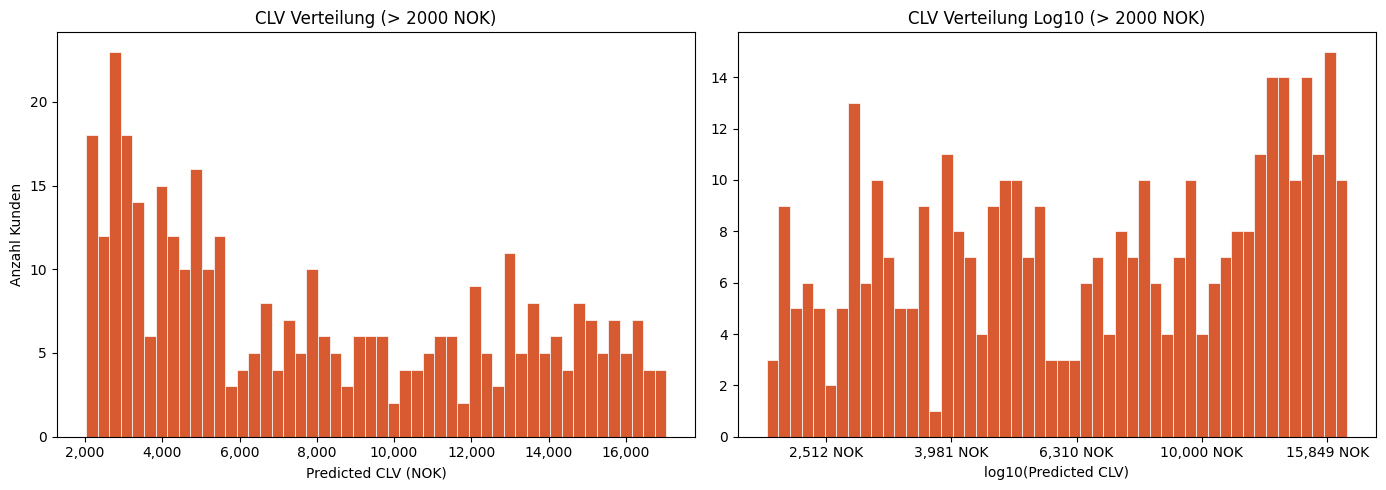

In [8]:
clv_high = test["revenue_23_24_baseline_CLVEuler"][
    (test["revenue_23_24_baseline_CLVEuler"] > 2000) &
    (test["revenue_23_24_baseline_CLVEuler"] < test["revenue_23_24_baseline_CLVEuler"].quantile(0.95))
]
print(f"Kunden über 2000 NOK: {len(clv_high)} ({len(clv_high)/len(test)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].hist(clv_high, bins=50, color="#D85A30", edgecolor="white", linewidth=0.5)
axes[0].set_title("CLV Verteilung (> 2000 NOK)")
axes[0].set_xlabel("Predicted CLV (NOK)")
axes[0].set_ylabel("Anzahl Kunden")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Log
axes[1].hist(np.log10(clv_high), bins=50, color="#D85A30", edgecolor="white", linewidth=0.5)
axes[1].set_title("CLV Verteilung Log10 (> 2000 NOK)")
axes[1].set_xlabel("log10(Predicted CLV)")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{10**x:,.0f} NOK"))

plt.tight_layout()
plt.show()